In [62]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np

In [63]:
result_dir = Path("results3")
metrics = [
  "l1_dcache.WriteReq.misses::total",
  "l1_dcache.ReadReq.misses::total",
  "l1_dcache.WriteReq.hits::total",
  "l1_dcache.ReadReq.hits::total",
  "l2_cache.overallHits::total",
  "l2_cache.overallMisses::total",
  "board.processor.cores.core.iew.branchMispredicts",
  "board.processor.cores.core.cpi",
  ]

In [103]:
results = []
data_str = ""

for i, dir in enumerate(result_dir.glob("*")):
  name = dir.name
  stat_file = dir / "stats.txt"

  if(i == 0):
    params = [[] for i in range((len(name.split("_")) -1))] 

  curr = []
  index = []
  for j, thing in enumerate(name.split("_")[1:]):
      store = params[j]
      if(thing not in store):
        store.append(thing)
      index.append(store.index(thing))
      curr.append(thing)

  print(index)
  
  with open(stat_file) as result_file:
   content = result_file.read()
   for metric in metrics:
    matcher = f"{metric}[ ]*([0-9].[0-9]*)" 

    metric_search = re.search(matcher, content, re.IGNORECASE)
    if metric_search:
        result = float(metric_search.group(1))
    
    results.append([index, metric, result])

    out_str = (f"{curr[0]} | {curr[1]} | Metric: {metric.split(".")[-1]}:  {result}\n")
    data_str += out_str
    print(out_str) 

[0, 0, 0]
L11kB | L232kB | Metric: misses::total:  8553.0

L11kB | L232kB | Metric: misses::total:  19833932.0

L11kB | L232kB | Metric: hits::total:  16924080.0

L11kB | L232kB | Metric: hits::total:  31410033.0

L11kB | L232kB | Metric: overallHits::total:  29945040.0

L11kB | L232kB | Metric: overallMisses::total:  74150.0

L11kB | L232kB | Metric: branchMispredicts:  74150.0

L11kB | L232kB | Metric: cpi:  3.693104

[0, 0, 1]
L11kB | L232kB | Metric: misses::total:  8553.0

L11kB | L232kB | Metric: misses::total:  19833940.0

L11kB | L232kB | Metric: hits::total:  16924103.0

L11kB | L232kB | Metric: hits::total:  31409793.0

L11kB | L232kB | Metric: overallHits::total:  29947494.0

L11kB | L232kB | Metric: overallMisses::total:  71808.0

L11kB | L232kB | Metric: branchMispredicts:  71808.0

L11kB | L232kB | Metric: cpi:  3.693779

[0, 0, 2]
L11kB | L232kB | Metric: misses::total:  8553.0

L11kB | L232kB | Metric: misses::total:  19833928.0

L11kB | L232kB | Metric: hits::total:  1

In [65]:
results

[[[0, 0, 0], 'l1_dcache.WriteReq.misses::total', 8553.0],
 [[0, 0, 0], 'l1_dcache.ReadReq.misses::total', 19833932.0],
 [[0, 0, 0], 'l1_dcache.WriteReq.hits::total', 16924080.0],
 [[0, 0, 0], 'l1_dcache.ReadReq.hits::total', 31410033.0],
 [[0, 0, 0], 'l2_cache.overallHits::total', 29945040.0],
 [[0, 0, 0], 'l2_cache.overallMisses::total', 74150.0],
 [[0, 0, 0], 'board.processor.cores.core.iew.branchMispredicts', 74150.0],
 [[0, 0, 0], 'board.processor.cores.core.cpi', 3.693104],
 [[0, 0, 1], 'l1_dcache.WriteReq.misses::total', 8553.0],
 [[0, 0, 1], 'l1_dcache.ReadReq.misses::total', 19833940.0],
 [[0, 0, 1], 'l1_dcache.WriteReq.hits::total', 16924103.0],
 [[0, 0, 1], 'l1_dcache.ReadReq.hits::total', 31409793.0],
 [[0, 0, 1], 'l2_cache.overallHits::total', 29947494.0],
 [[0, 0, 1], 'l2_cache.overallMisses::total', 71808.0],
 [[0, 0, 1], 'board.processor.cores.core.iew.branchMispredicts', 71808.0],
 [[0, 0, 1], 'board.processor.cores.core.cpi', 3.693779],
 [[0, 0, 2], 'l1_dcache.WriteReq

In [66]:
def get_heatmap_data_from_res(res):
  for metric in metrics:
    data = np.zeros([len(i) for i in params])
    for r in res:
      if(r[1] == metric):
        indx = r[0]
        data[*indx] = r[2]
    yield (params, data, metric)


In [67]:
heatm_folder = Path("heatmaps3")

In [78]:
def create_heatmap(x_names, y_names, data,metric):
  fig, ax = plt.subplots()
  im = ax.imshow(data)

  # Show all ticks and label them with the respective list entries
  ax.set_xticks(range(len(y_names)), labels=y_names,
                rotation=45, ha="right", rotation_mode="anchor")
  ax.set_yticks(range(len(x_names)), labels=x_names)

  # Loop over data dimensions and create text annotations.
  for i in range(len(x_names)):
      for j in range(len(y_names)):
          text = ax.text(j, i, data[i, j],
                        ha="center", va="center", color="w")

  ax.set_title(metric)
  ax.set_ylabel("L1 size")
  ax.set_xlabel("L2 size")
  fig.tight_layout()
  return fig

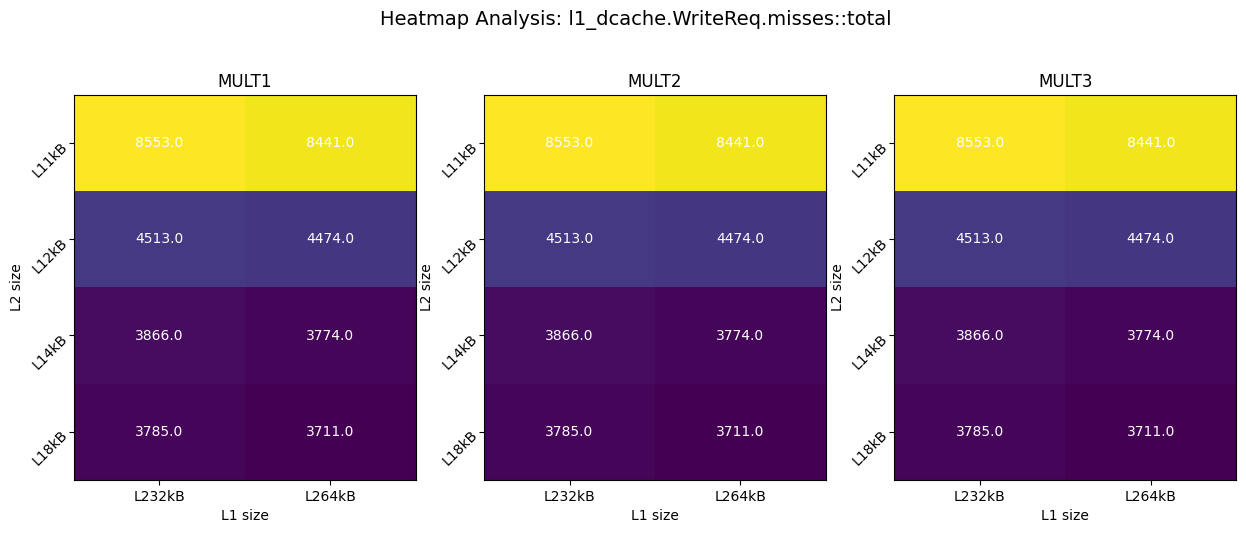

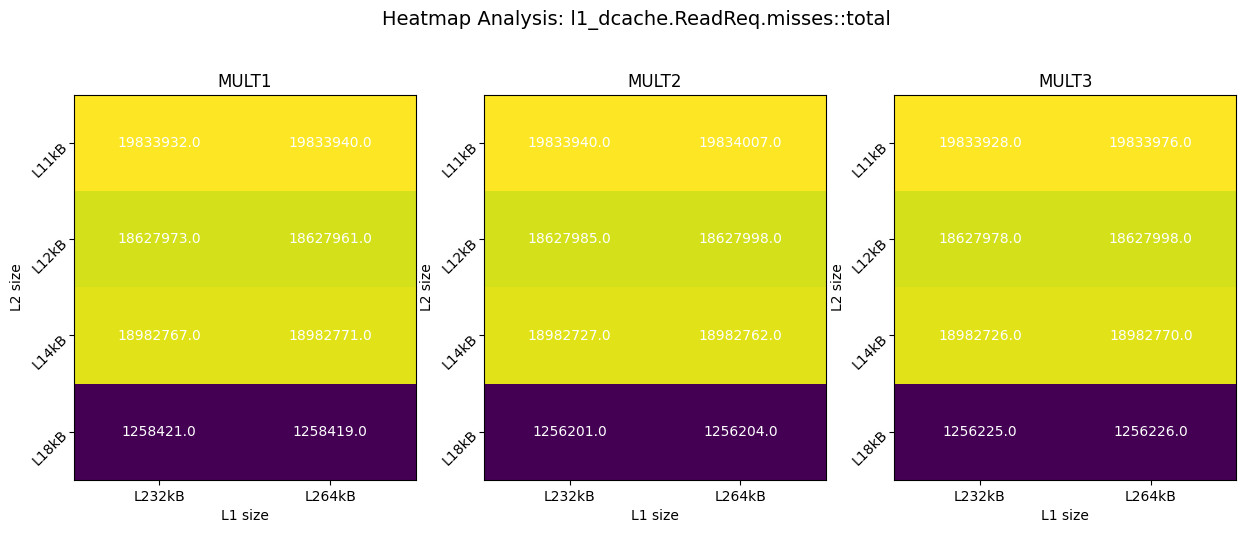

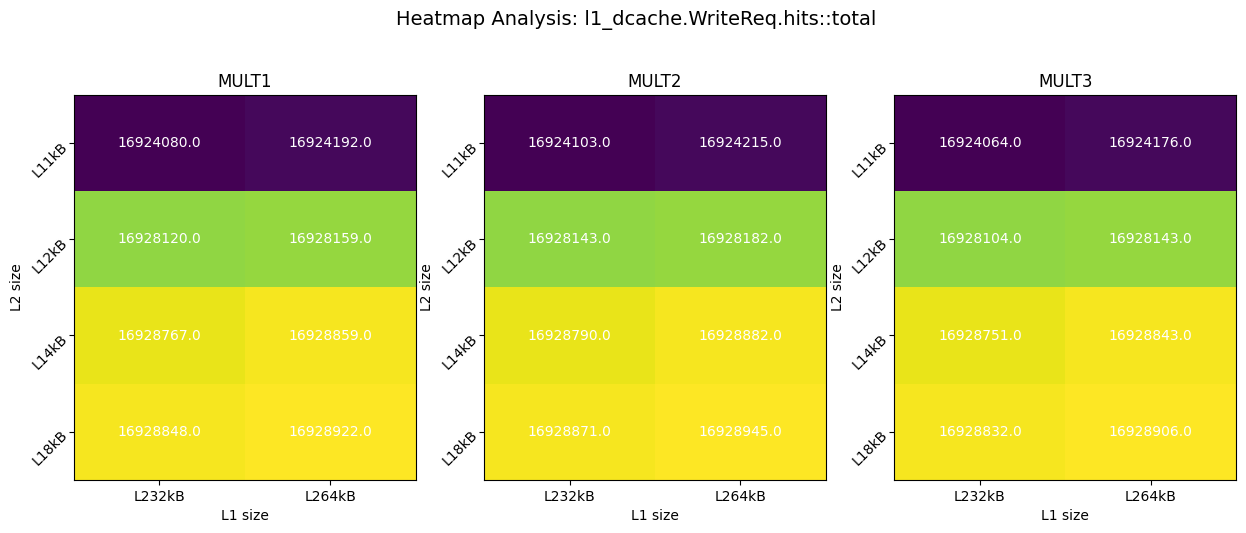

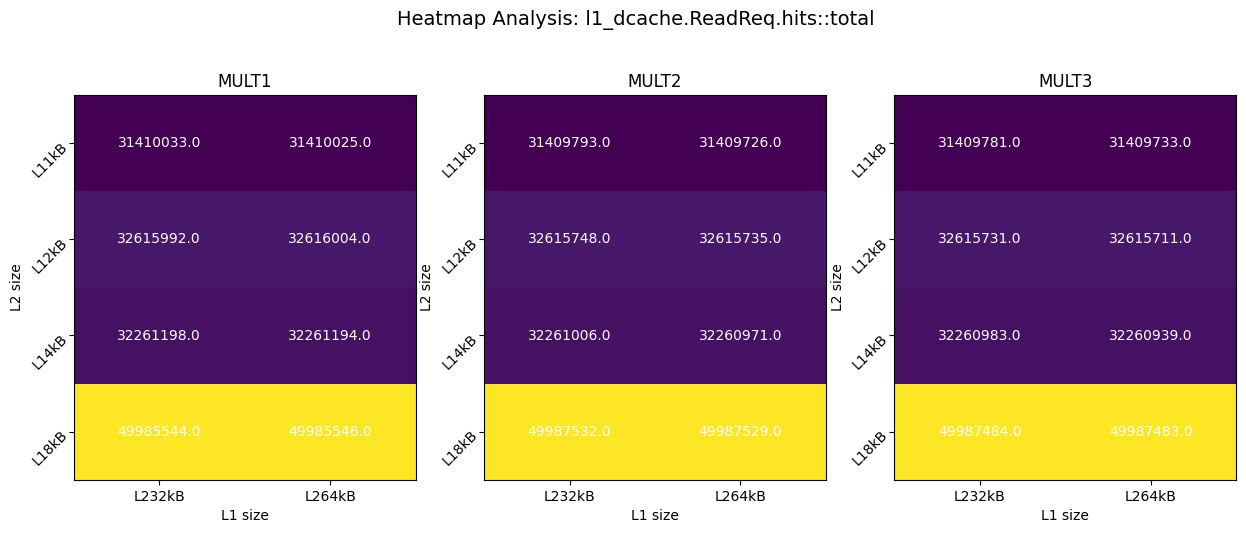

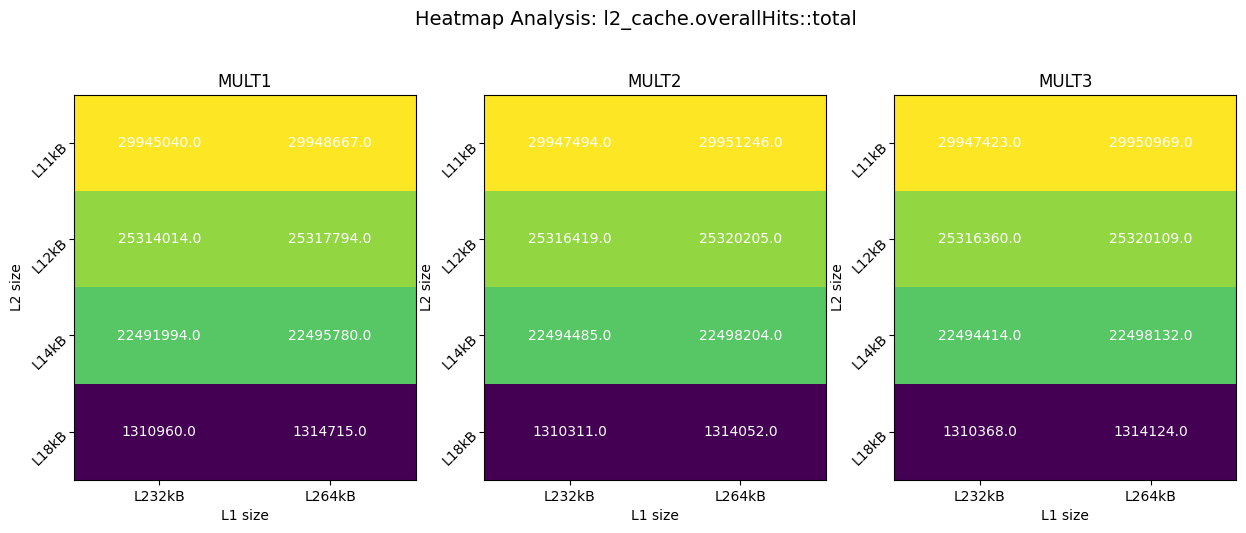

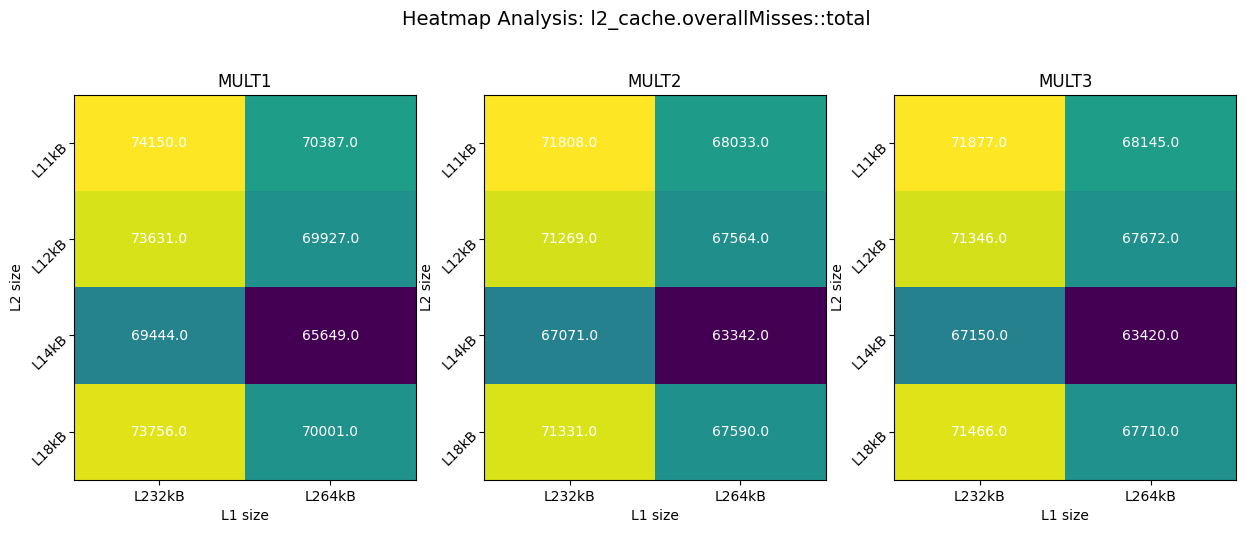

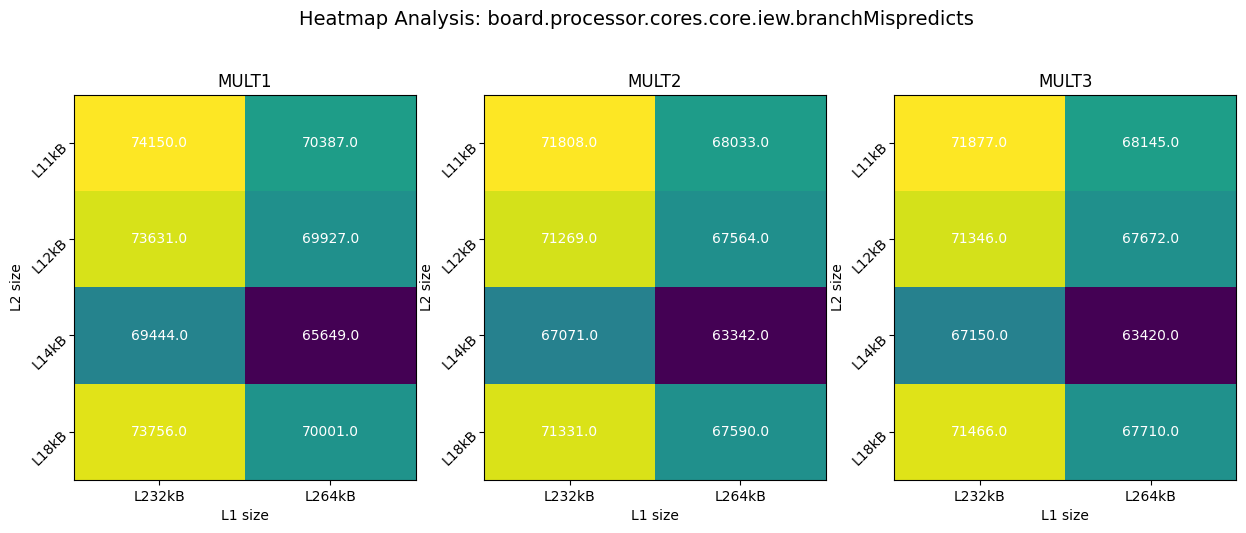

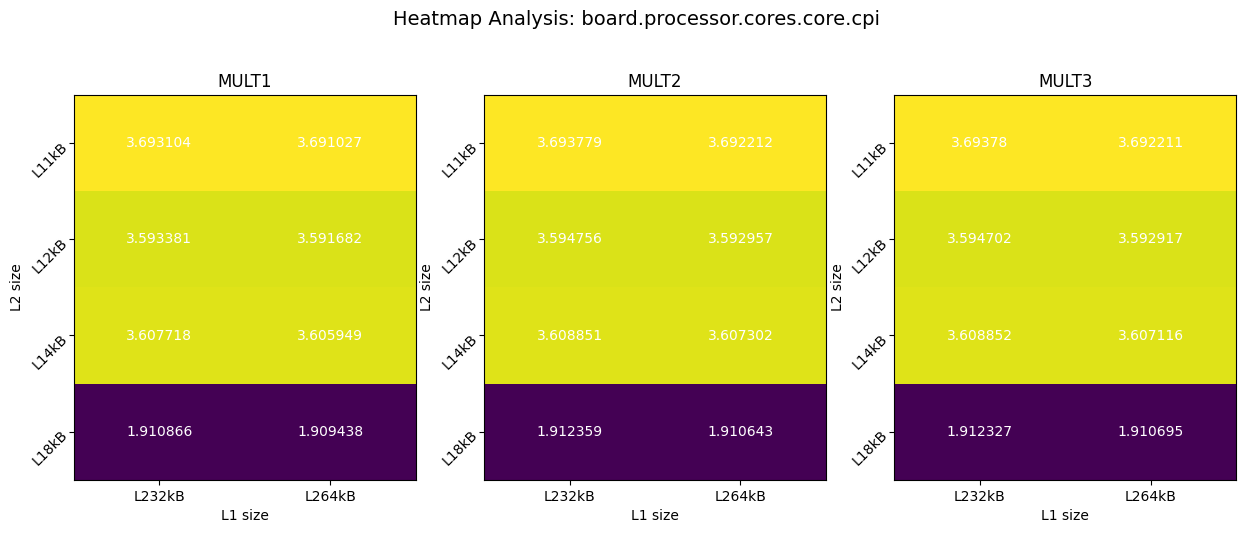

In [111]:
for out in get_heatmap_data_from_res(results):
    (params, data, metric) = out
    if len(params) == 2:
        figure = create_heatmap(params[0], params[1], data[:, :], metric)
    elif len(params) == 3:
        # Create a figure with multiple subplots (one for each value in params[2])
        n_cols = len(params[2])
        fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
        if n_cols == 1:
            axes = [axes]  # Ensure axes is always a list for consistency
            
        for b, (ax, value) in enumerate(zip(axes, params[2])):
              # Loop over data dimensions and create text annotations.
            for i in range(len(params[0])):
                for j in range(len(params[1])):
                    text = ax.text(j, i, data[i, j, b], ha="center", va="center", color="w")
            im = ax.imshow(data[:, :, b], aspect='auto', cmap="viridis")
            ax.set_title(value)
            ax.set_xlabel(params[0].name if hasattr(params[0], 'name') else 'L1 size')
            ax.set_ylabel(params[1].name if hasattr(params[1], 'name') else 'L2 size')
            ax.set_yticks(range(len(params[0])), labels=params[0],
                rotation=45, ha="right", rotation_mode="anchor")
            ax.set_xticks(range(len(params[1])), labels=params[1])
            ax.set_label(metric)
            #fig.colorbar(im, ax=ax, label=metric)
        
        fig.suptitle(f"Heatmap Analysis: {metric}", y=1.05, fontsize=14)
        figure = fig
        figure.savefig(f"heatmaps3/Heatmap_{metric}.png")
    else:
        raise ValueError("params must have length 2 or 3")

In [107]:
data_str

'L11kB | L232kB | Metric: misses::total:  8553.0\nL11kB | L232kB | Metric: misses::total:  19833932.0\nL11kB | L232kB | Metric: hits::total:  16924080.0\nL11kB | L232kB | Metric: hits::total:  31410033.0\nL11kB | L232kB | Metric: overallHits::total:  29945040.0\nL11kB | L232kB | Metric: overallMisses::total:  74150.0\nL11kB | L232kB | Metric: branchMispredicts:  74150.0\nL11kB | L232kB | Metric: cpi:  3.693104\nL11kB | L232kB | Metric: misses::total:  8553.0\nL11kB | L232kB | Metric: misses::total:  19833940.0\nL11kB | L232kB | Metric: hits::total:  16924103.0\nL11kB | L232kB | Metric: hits::total:  31409793.0\nL11kB | L232kB | Metric: overallHits::total:  29947494.0\nL11kB | L232kB | Metric: overallMisses::total:  71808.0\nL11kB | L232kB | Metric: branchMispredicts:  71808.0\nL11kB | L232kB | Metric: cpi:  3.693779\nL11kB | L232kB | Metric: misses::total:  8553.0\nL11kB | L232kB | Metric: misses::total:  19833928.0\nL11kB | L232kB | Metric: hits::total:  16924064.0\nL11kB | L232kB | M